# Pion Stop Finder (Upgraded)

This notebook trains a `PionStopRegressor` to predict the true stopping point of pions.
It uses the standardized `GraphRecord` and `GraphGroupDataset` infrastructure, loading explicit
ground truth endpoints from `group_info` metadata files rather than inferring them from hits.

In [1]:
import sys, os
import glob
import re
import math
from typing import List, Optional, Tuple, Dict, Any
import numpy as np
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.loader import DataLoader
from torch.nn.utils import clip_grad_norm_

PROJECT_ROOT = "/mnt/c/Users/obbee/research/notebooks/ML"
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)
    os.environ["PYTHONPATH"] = PROJECT_ROOT + os.pathsep + os.environ.get("PYTHONPATH", "")

from graph_data.utils import GraphRecord, GraphGroupDataset
from graph_data.models import PionStopRegressor
from graph_data.plotting import plot_event_display

/home/omar/miniconda3/envs/research/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [11]:
def load_pion_groups(
    npy_files: List[str],
    verbose: bool = True,
    limit_groups: Optional[int] = None
) -> List[GraphRecord]:
    """
    Loads groups containing pions and extracts true endpoint from metadata.
    Mimics structure of load_endpoint_groups in endpoint_finder.ipynb.
    """
    records = []
    
    if verbose:
        print(f"Found {len(npy_files)} hit files. Starting processing...")
    
    def extract_index(fname):
        match = re.search(r'hits_batch_(\d+)\.npy', fname)
        return int(match.group(1)) if match else -1
    
    paths = sorted(npy_files, key=extract_index)
    
    for path in tqdm(paths, desc="Processing Files", disable=not verbose):

        if limit_groups and len(records) >= limit_groups:
            break

        try:
            chunk_data = np.load(path, allow_pickle=True)
            batch_idx = extract_index(path)
            info_path = path.replace(f"hits_batch_{batch_idx}.npy", f"group_info_batch_{batch_idx}.npy")
            info_data = np.load(info_path, allow_pickle=True)
        except Exception as e:
            print(f"Error loading {path}: {e}")
            continue
            
        for group_offset, (group, g_info) in enumerate(zip(chunk_data, info_data)):
            if limit_groups and len(records) >= limit_groups:
                break

            if len(group) < 2:
                continue
                
            group = np.array(group)
            
            # Extract features
            coord = group[:, 0].astype(np.float32)
            z_pos = group[:, 1].astype(np.float32)
            view_flag = group[:, 2].astype(np.float32)
            energy = group[:, 3].astype(np.float32)
            
            # Extract PDG mask (index 4)
            hit_masks = group[:, 4].astype(int)
            is_pion = (hit_masks & 1) != 0
            
            # Filter: If NO pion hits, skip it
            if not is_pion.any():
                continue
            
            # Extract True Pion Stop from g_info (Indices 3, 4, 5) per user correction
            true_pion_stop = [g_info[3], g_info[4], g_info[5]]

            # Create labels for GraphRecord
            is_muon = (hit_masks & 2) != 0
            is_mip = ((hit_masks & 4) != 0) | ((hit_masks & 8) != 0)
            
            # Calculate class energies
            hit_labels = np.stack([is_pion, is_muon, is_mip], axis=1).astype(np.float32)
            class_energies = hit_labels.T @ energy
            
            # Create hit_pdgs efficiently (Vectorized)
            #hit_pdgs = np.zeros(len(group), dtype=int)
            #hit_pdgs[is_pion] = 1
            #hit_pdgs[is_muon] = 2
            #hit_pdgs[is_mip] = 4

            record_event_id = int(g_info[11])

            records.append(GraphRecord(
                coord=coord,
                z=z_pos,
                view=view_flag,
                energy=energy,
                class_energies=class_energies,
                true_pion_stop=true_pion_stop,
                hit_pdgs=hit_masks,
                event_id=record_event_id,
                group_id=len(records)
            ))
            
    if verbose:
        print(f"Loaded {len(records)} pion groups.")

    return records

In [12]:
data_dir = "npy_data"
npy_files = glob.glob(os.path.join(data_dir, "hits_batch_*.npy"))

# Load pion groups
pion_groups = load_pion_groups(npy_files, limit_groups=20000)

# Split Train/Val
rng = np.random.default_rng(42)
rng.shuffle(pion_groups)

split_idx = int(0.85 * len(pion_groups))
train_groups = pion_groups[:split_idx]
val_groups = pion_groups[split_idx:]

print(f"Train: {len(train_groups)}, Val: {len(val_groups)}")

Found 289 hit files. Starting processing...


Processing Files:   2%|▏         | 6/289 [01:40<1:19:16, 16.81s/it]

Loaded 20000 pion groups.
Train: 17000, Val: 3000


In [13]:
def _distance_histogram(distances: np.ndarray | List[float], bins: int = 50, span=(0.0, 2.0)):
    values = np.asarray(distances, dtype=np.float32)
    if values.size == 0:
        return None
    counts, edges = np.histogram(values, bins=bins, range=span)
    return {
        'counts': counts.tolist(),
        'bin_edges': edges.tolist(),
    }

def _plot_histogram(title: str, hist_data: Optional[Dict[str, Any]]) -> None:
    if hist_data is None:
        return
    counts = np.asarray(hist_data['counts'], dtype=np.float32)
    edges = np.asarray(hist_data['bin_edges'], dtype=np.float32)
    if counts.size == 0 or edges.size == 0:
        return
    centers = 0.5 * (edges[:-1] + edges[1:])
    widths = np.diff(edges)
    fig, axes = plt.subplots(1, 2, figsize=(10, 3))
    for ax, log_scale in zip(axes, [False, True]):
        ax.bar(centers, counts, width=widths, align='center', alpha=0.75, color='teal')
        ax.set_title(f"{title} pion-stop error histogram" + (' (log)' if log_scale else ''))
        ax.set_xlabel('Euclidean error [mm]')
        ax.set_ylabel('Counts')
        ax.set_xlim(0.0, 2.0)
        if log_scale:
            ax.set_yscale('log')
        ax.grid(True, linestyle='--', alpha=0.3)
    plt.tight_layout()
    plt.show()

def plot_training_curves(train_losses, val_losses, train_dists, val_dists):
    """
    Plots the training and validation history curves.
    """
    fig, ax = plt.subplots(1, 2, figsize=(15, 5))
    
    # Loss Plot
    ax[0].plot(train_losses, label='Train Loss', marker='o')
    ax[0].plot(val_losses, label='Val Loss', marker='o')
    ax[0].set_xlabel('Epoch')
    ax[0].set_ylabel('MSE Loss')
    ax[0].set_title('Training vs Validation Loss')
    ax[0].legend()
    ax[0].grid(True)
    
    # Distance Plot
    ax[1].plot(train_dists, label='Train Dist (mm)', marker='o')
    ax[1].plot(val_dists, label='Val Dist (mm)', marker='o')
    ax[1].set_xlabel('Epoch')
    ax[1].set_ylabel('Euclidean Distance Error (mm)')
    ax[1].set_title('Training vs Validation Distance Error')
    ax[1].legend()
    ax[1].grid(True)
    
    plt.tight_layout()
    plt.show()

def train_pion_stop(
    model: nn.Module,
    train_groups: List[GraphRecord],
    val_groups: List[GraphRecord],
    device='cuda',
    batch_size=128,
    epochs=20,
    lr=1e-3,
    weight_decay=1e-5
) -> Tuple[nn.Module, DataLoader, torch.device]:
    """
    Trains the PionStopRegressor model with live plotting.
    Now accepts an externally defined model instance.
    """
    
    # Wrap lists in GraphGroupDataset so DataLoader gets Data objects
    train_dataset = GraphGroupDataset(train_groups)
    val_dataset = GraphGroupDataset(val_groups)
    
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
    
    device_obj = torch.device(device if torch.cuda.is_available() else 'cpu')
    print(f"Using device: {device_obj}")
    
    model = model.to(device_obj)
    
    # Optimizer with configurable weight decay
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=3)
    
    criterion = torch.nn.MSELoss()
    
    print("Starting training...")
    
    train_losses = []
    val_losses = []
    train_dists = []
    val_dists = []
    
    for epoch in range(1, epochs + 1):
        model.train()
        train_loss = 0.0
        train_dist = 0.0
        
        # Collect individual distances for histogram
        current_train_dists = []
        
        for batch in train_loader:
            batch = batch.to(device_obj)
            optimizer.zero_grad()
            
            # Forward
            pred = model(batch) # [Batch, 3]
            
            # Target: Prefer y_pion_stop if available, else batch.y_pos[:, 1, :]
            target = batch.y_pion_stop.squeeze(1)
            
            loss = criterion(pred, target)
            loss.backward()
            clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            
            with torch.no_grad():
                train_loss += loss.item() * batch.num_graphs
                batch_dists = torch.norm(pred - target, dim=1) # [Batch]
                train_dist += batch_dists.sum().item()
                current_train_dists.append(batch_dists.cpu().numpy())
                
        avg_train_loss = train_loss / len(train_groups)
        avg_train_dist = train_dist / len(train_groups)
        all_train_dists = np.concatenate(current_train_dists) if current_train_dists else np.array([])
        
        # Validation
        model.train()
        val_loss = 0.0
        val_dist = 0.0
        current_val_dists = []
        
        with torch.no_grad():
            for batch in val_loader:
                batch = batch.to(device_obj)
                pred = model(batch)
                
                target = batch.y_pion_stop.squeeze(1)
                
                loss = criterion(pred, target)
                val_loss += loss.item() * batch.num_graphs
                batch_dists = torch.norm(pred - target, dim=1)
                val_dist += batch_dists.sum().item()
                current_val_dists.append(batch_dists.cpu().numpy())
        
        avg_val_loss = val_loss / len(val_groups)
        avg_val_dist = val_dist / len(val_groups)
        all_val_dists = np.concatenate(current_val_dists) if current_val_dists else np.array([])
        
        # Store history
        train_losses.append(avg_train_loss)
        val_losses.append(avg_val_loss)
        train_dists.append(avg_train_dist)
        val_dists.append(avg_val_dist)
        
        scheduler.step(avg_val_loss)
        current_lr = optimizer.param_groups[0]['lr']
        
        # Compute histograms
        train_hist = _distance_histogram(all_train_dists)
        val_hist = _distance_histogram(all_val_dists)
        
        # Live plot
        #clear_output(wait=True)
        
        # Plot curves
        plot_training_curves(train_losses, val_losses, train_dists, val_dists)
        
        # Plot histograms
        _plot_histogram('Train', train_hist)
        _plot_histogram('Validation', val_hist)
        
        print(f"Epoch {epoch:02d} | lr={current_lr:.5f} | "
              f"train_loss={avg_train_loss:.5f} dist={avg_train_dist:.4f} | "
              f"val_loss={avg_val_loss:.5f} dist={avg_val_dist:.4f}")
              
    return model, val_loader, device_obj

In [14]:
pion_model = PionStopRegressor(in_channels=4, hidden=150, heads=5, layers=3, dropout=0.05)

Using device: cuda
Starting training...


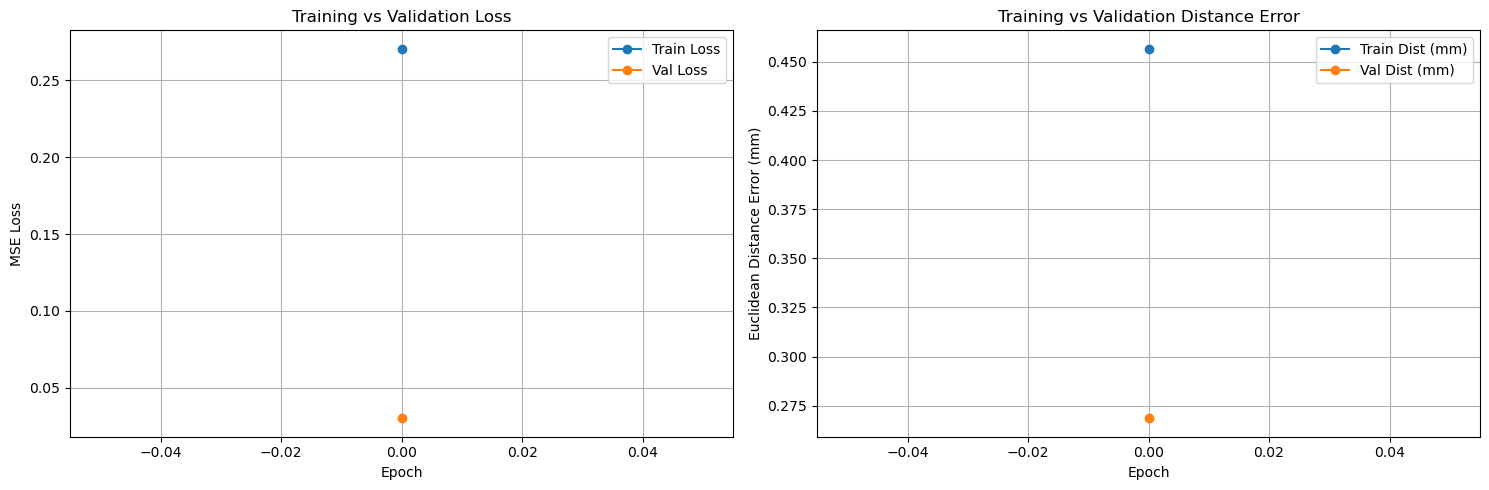

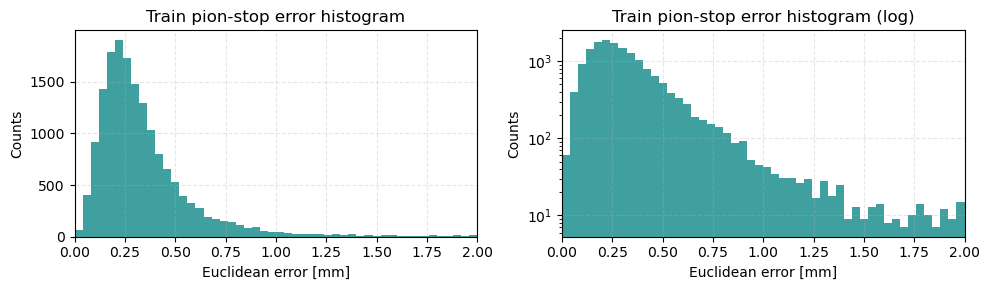

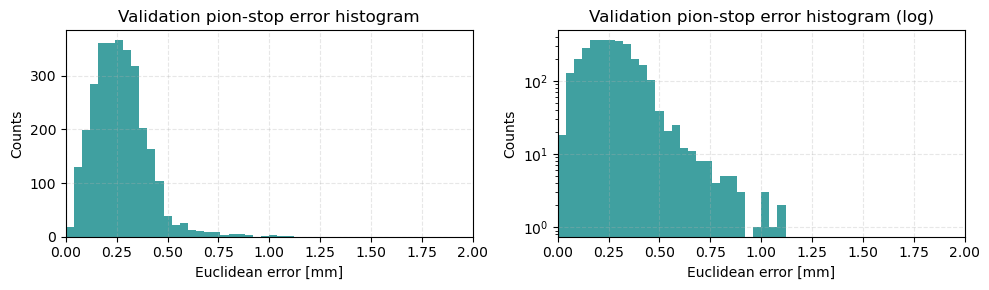

Epoch 01 | lr=0.00100 | train_loss=0.27052 dist=0.4566 | val_loss=0.03014 dist=0.2686


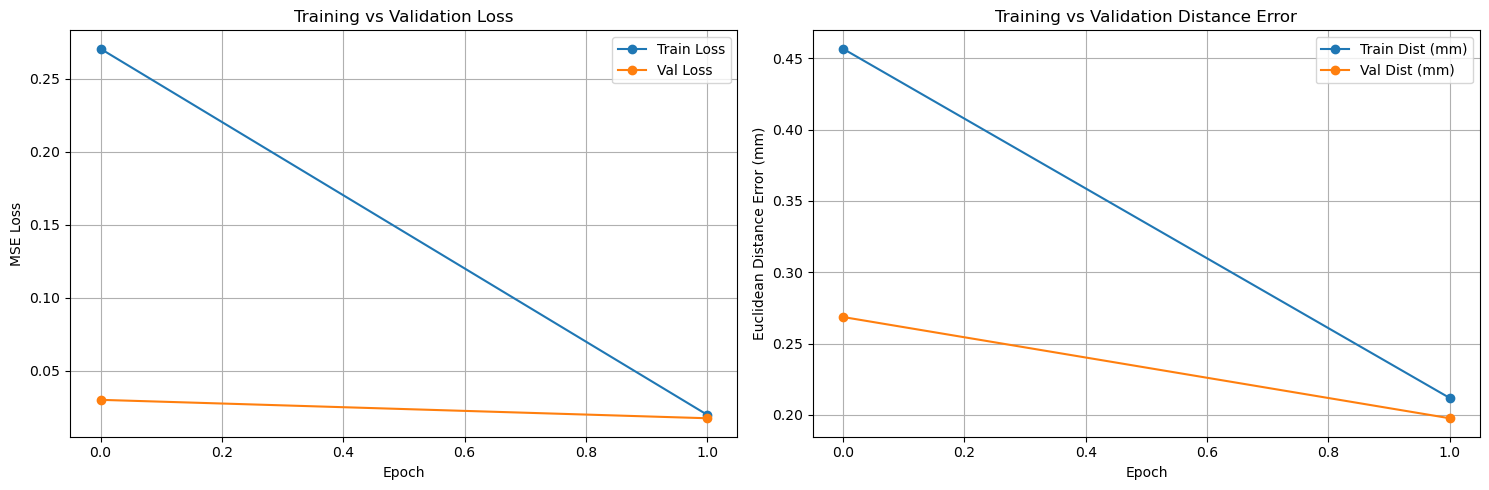

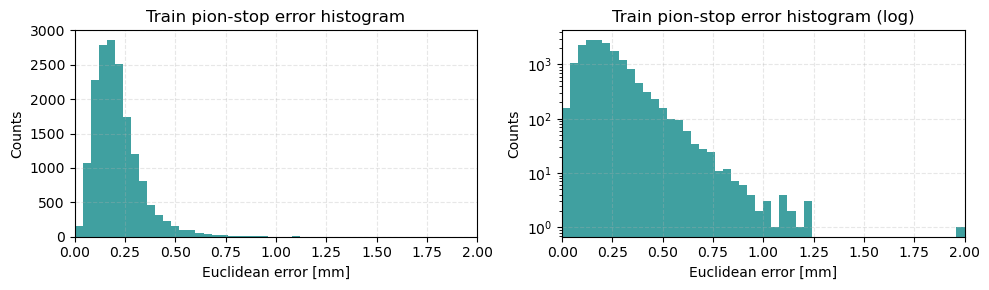

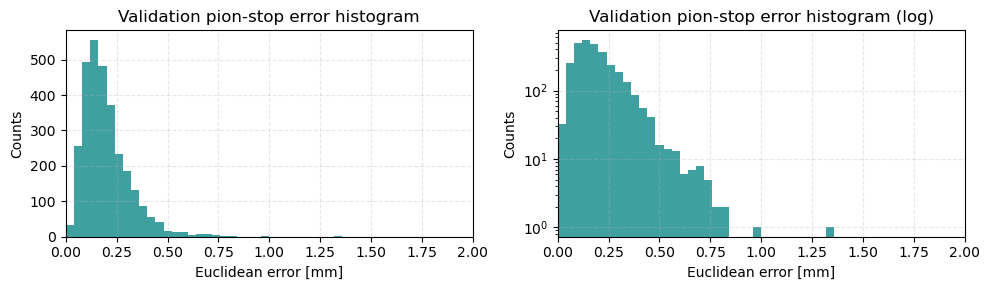

Epoch 02 | lr=0.00100 | train_loss=0.01991 dist=0.2119 | val_loss=0.01753 dist=0.1977


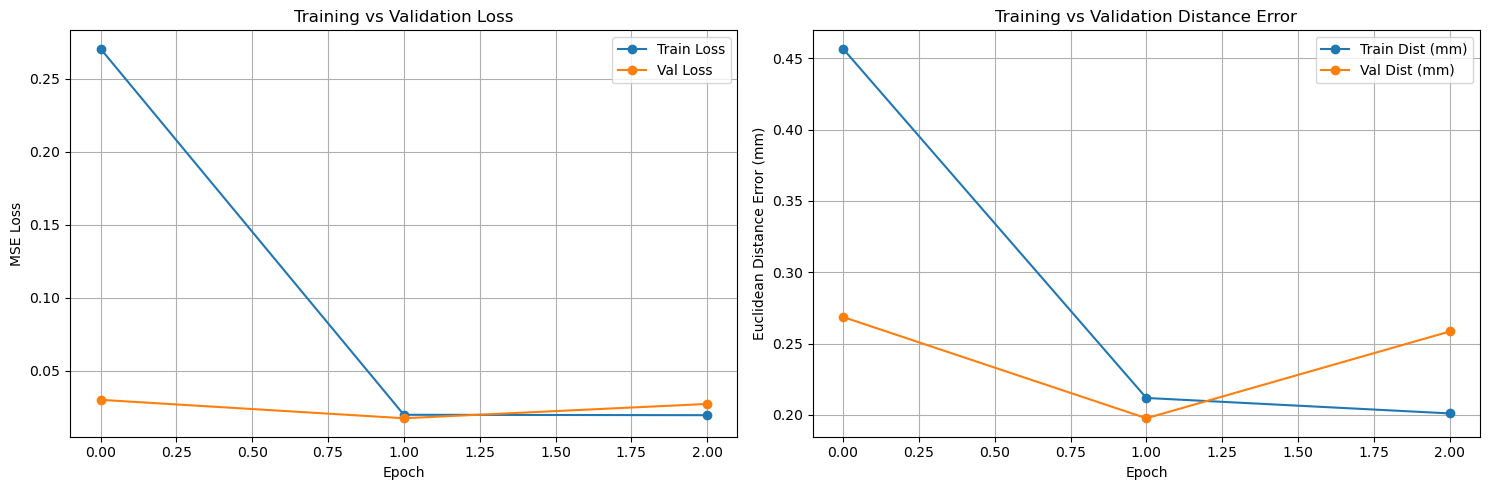

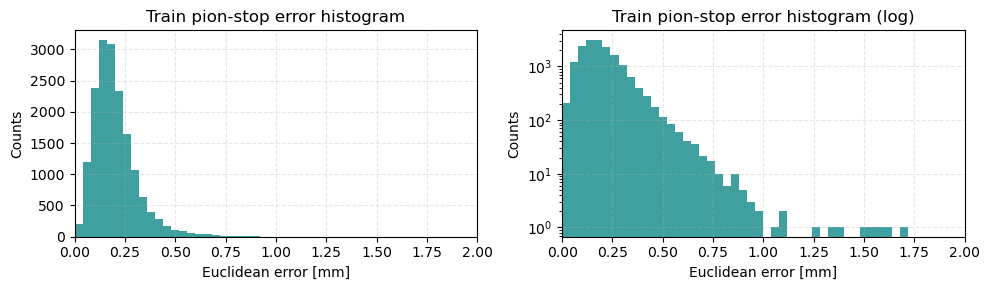

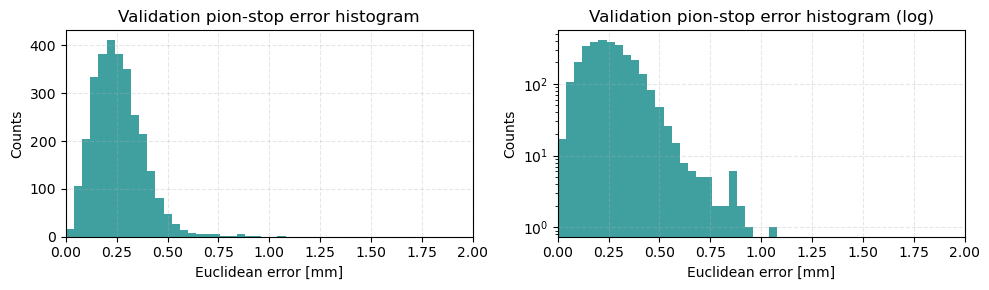

Epoch 03 | lr=0.00100 | train_loss=0.01963 dist=0.2011 | val_loss=0.02734 dist=0.2585


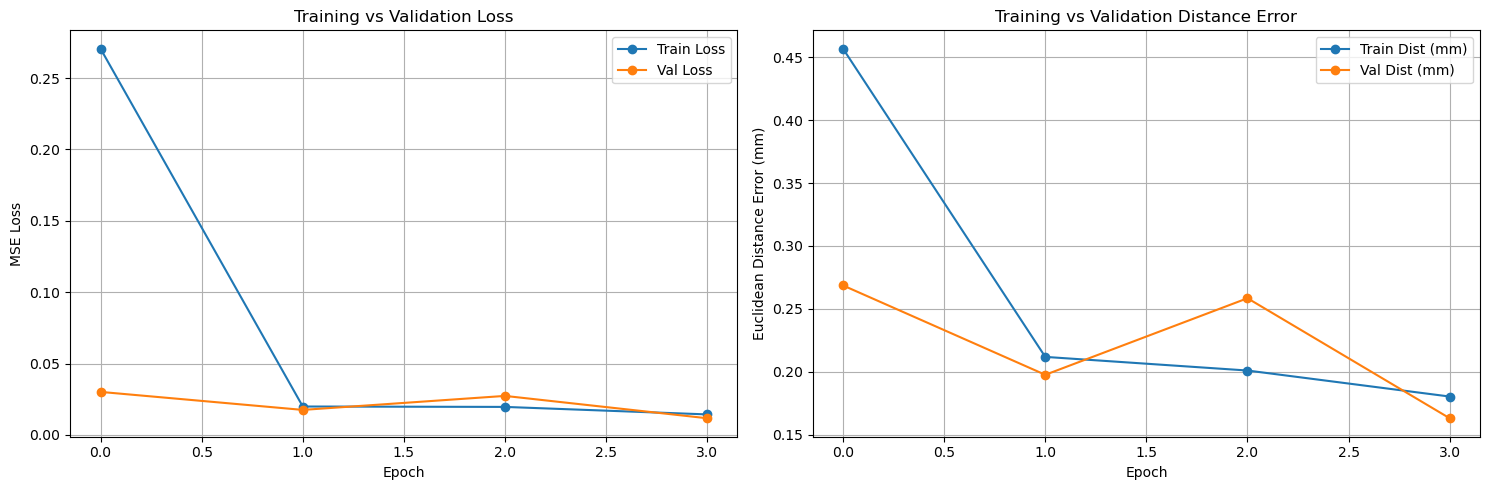

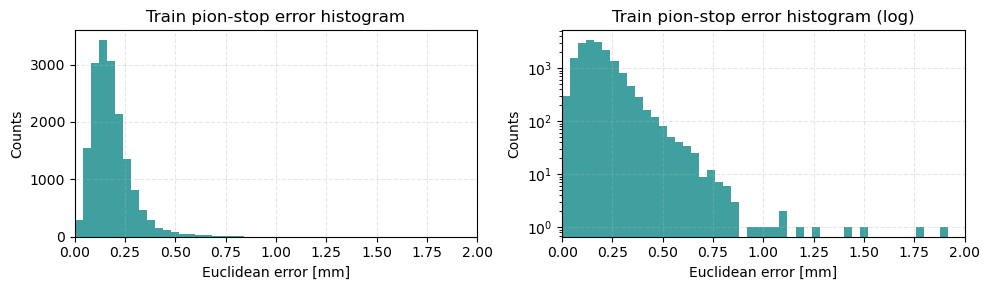

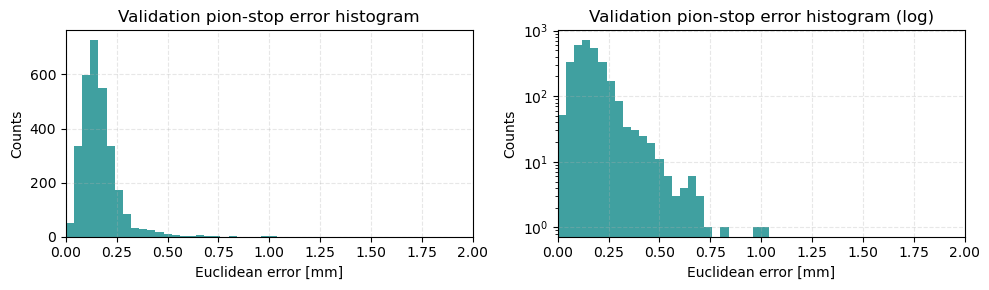

Epoch 04 | lr=0.00100 | train_loss=0.01437 dist=0.1804 | val_loss=0.01168 dist=0.1632


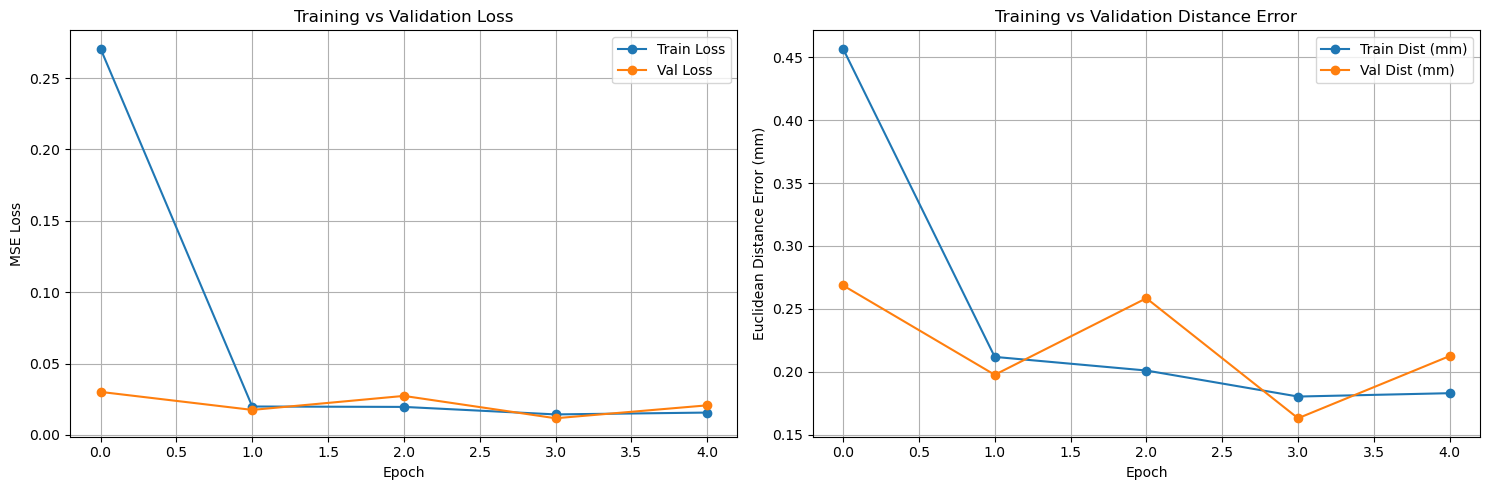

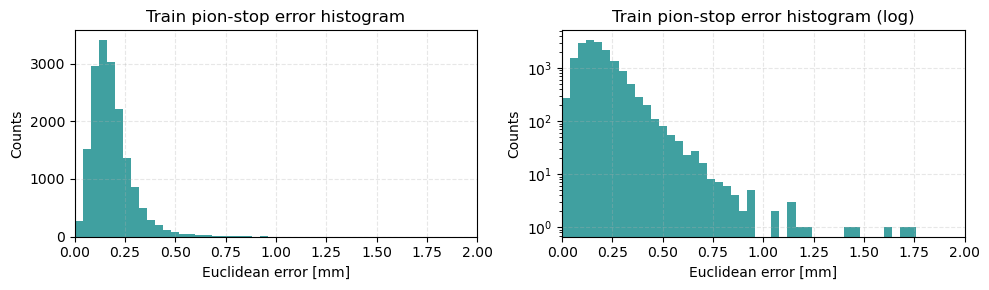

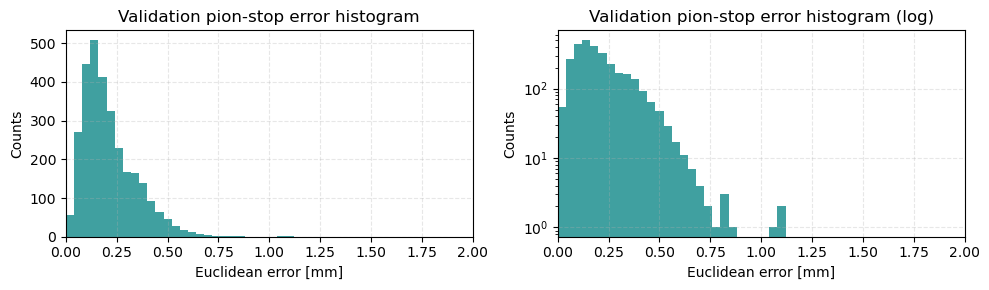

Epoch 05 | lr=0.00100 | train_loss=0.01566 dist=0.1831 | val_loss=0.02073 dist=0.2126


In [15]:
model, val_loader, device = train_pion_stop(
    pion_model,
    train_groups, 
    val_groups, 
    epochs=5, 
    batch_size=32
)

#TO DO: Why does the model have decreasing accuracy on the validation set, despite increasing accuracy on the training set?

Scanning validation set for failures...
Top 5 Worst Failures (Distance Error in mm):
#1: Error = 0.77 mm


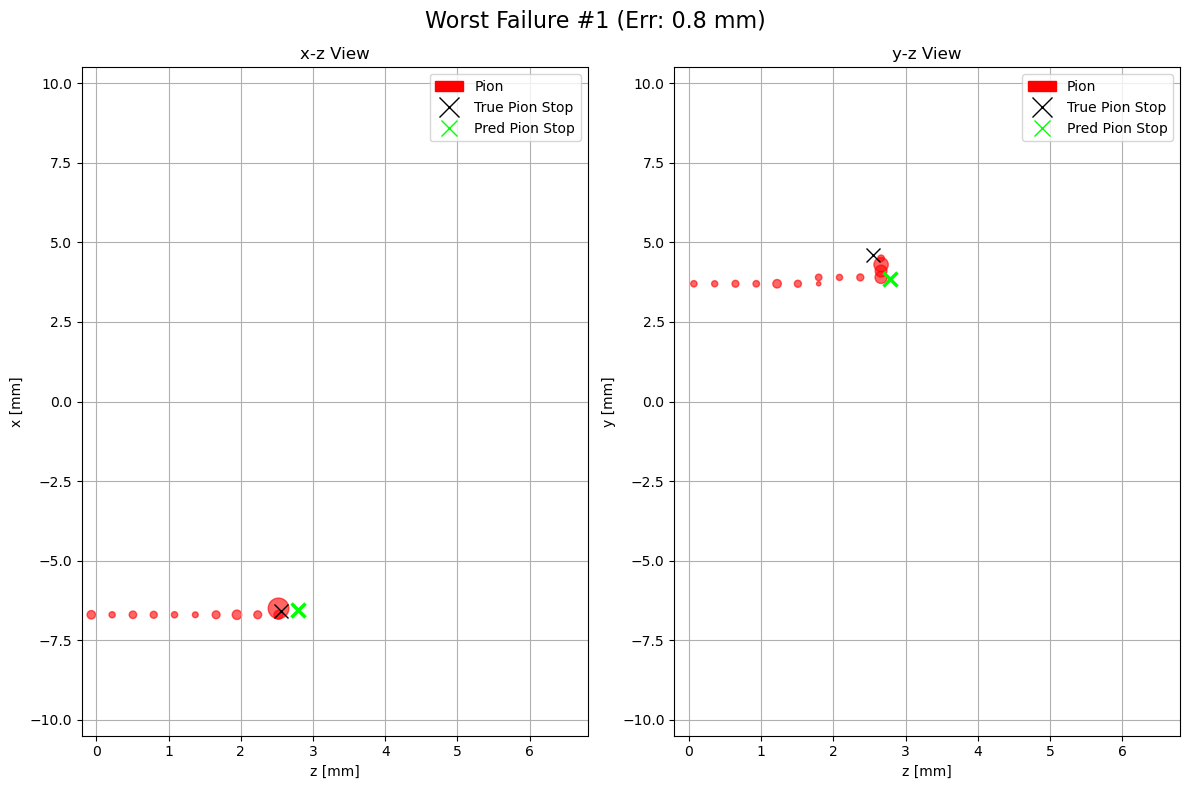

#2: Error = 0.70 mm


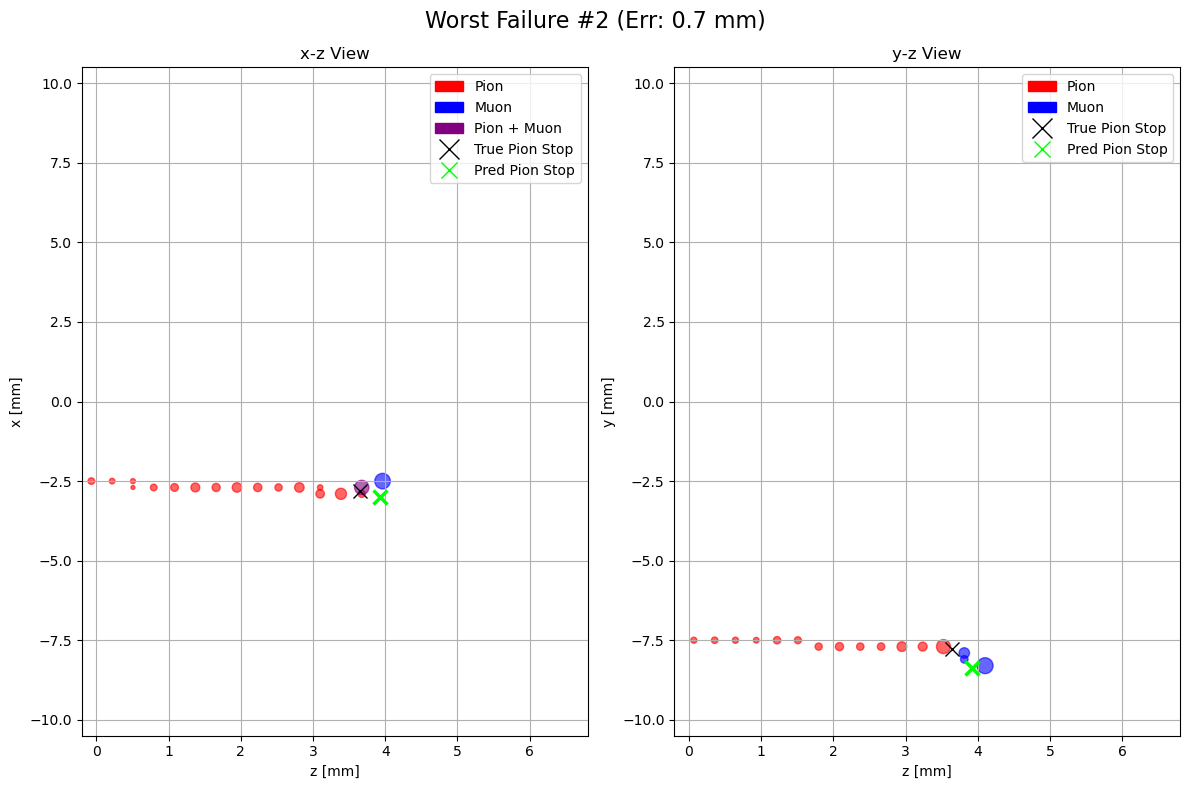

#3: Error = 0.70 mm


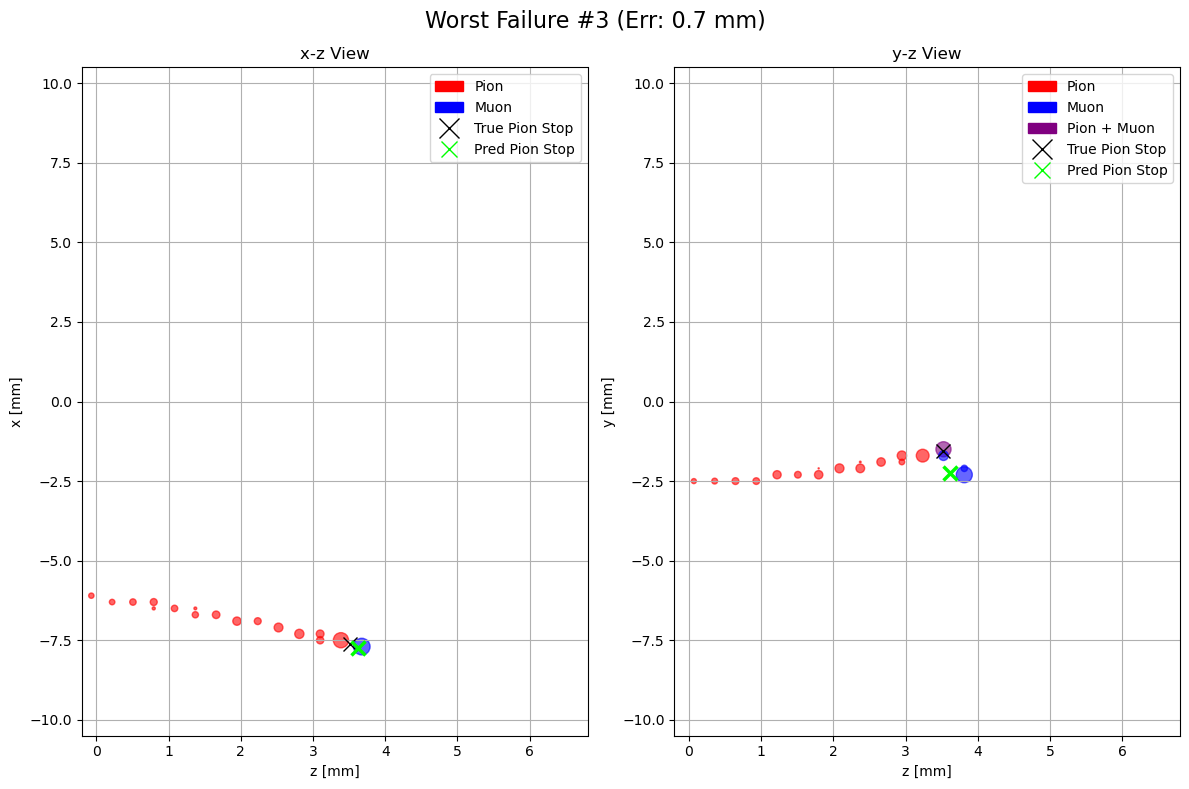

#4: Error = 0.67 mm


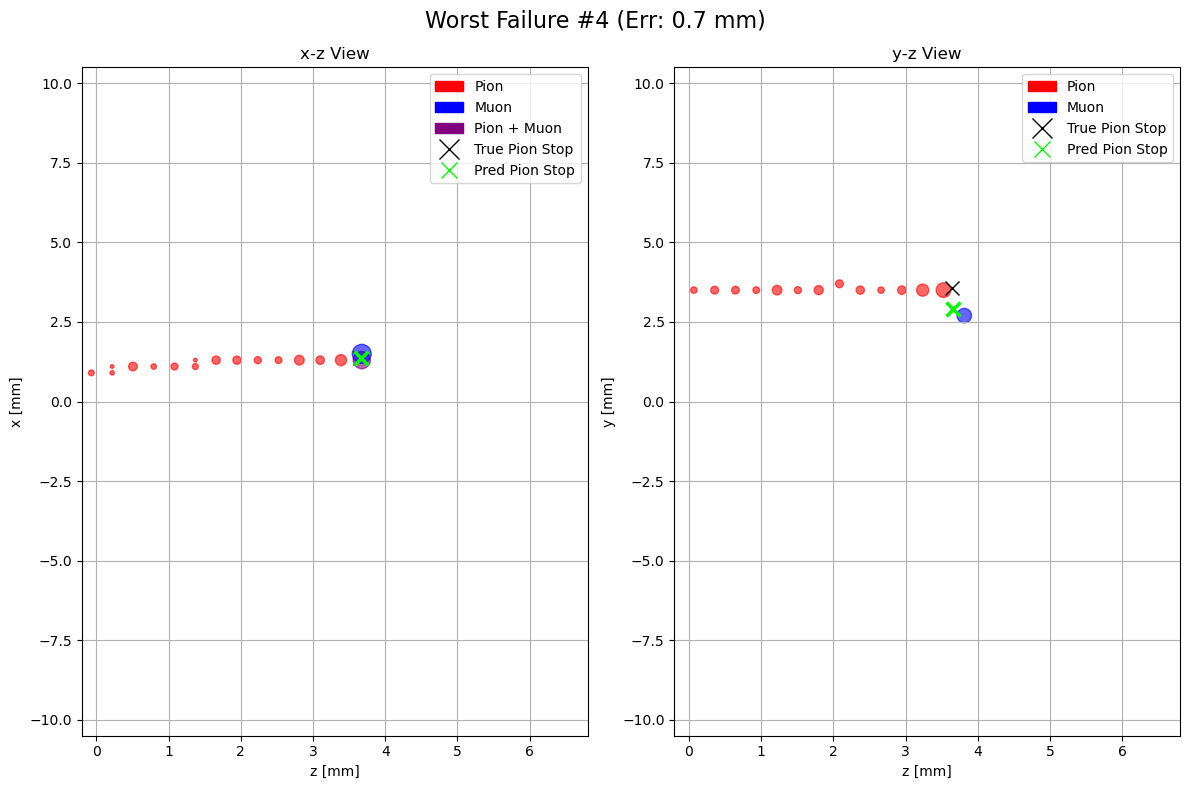

#5: Error = 0.61 mm


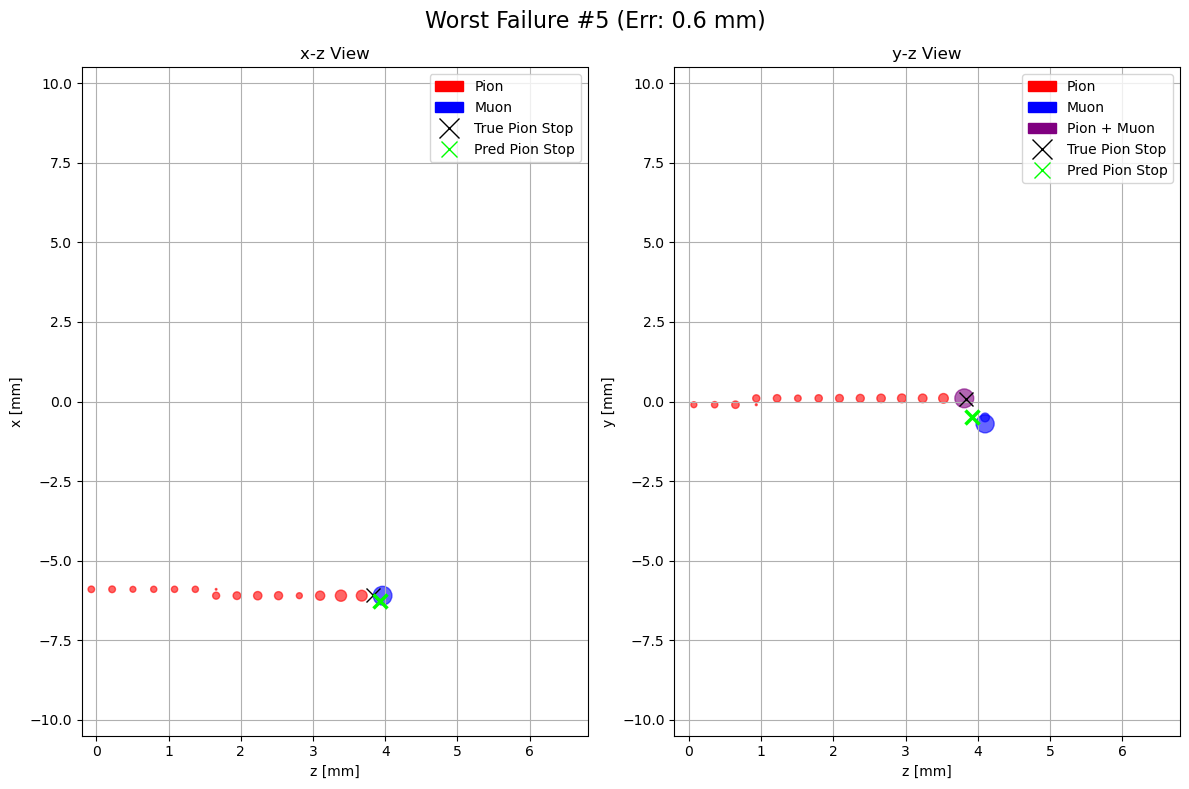

In [24]:
import importlib
import graph_data.plotting
importlib.reload(graph_data.plotting)
from graph_data.plotting import plot_pion_stop_events

def show_pion_stop_failures(model, loader, device='cuda', num_show=5, worst_n=10):
    """
    Finds events with the largest prediction error and plots them.
    """
    model.eval()
    all_losses = []
    all_records = []
    all_preds = []
    
    print("Scanning validation set for failures...")
    
    with torch.no_grad():
        for batch in loader:
            batch = batch.to(device)
            # 1. Capture Records BEFORE model inference destroys batch structure if needed
            # (GraphGroupDataset batches preserve the original list structure usually via custom collate or just indexing if simple)
            # But safer to assume 'batch' corresponds to a list of records if using standard PyG loader
            
            # Actually, we need the original GraphRecord objects to plot.
            # The DataLoader produces a Batch object. We can't easily get back GraphRecords 
            # unless we stored them or the dataset is indexable.
            
            # EASIER APPROACH: Iterate the dataset directly, not the loader, if small enough.
            # OR: Just assume valid_dataset reflects loader order.
            pass
    # REVISED APPROPRIATE APPROACH for Notebook:
    # Iterate over the DATASET indices to get records + predict one by one
    
    dataset = loader.dataset
    failures = []
    
    # Check a subset to be fast (e.g. first 500)
    indices = range(min(len(dataset), 500)) 
    
    with torch.no_grad():
        for idx in indices:
            # Get data object for model
            data = dataset[idx]
            # Get original record for plotting (dataset.items holds the records)
            record = dataset.items[idx]
            
            # Predict
            data = data.to(device)
            # Add batch dimension if needed
            if not hasattr(data, 'batch'):
                data.batch = torch.zeros(data.num_nodes, dtype=torch.long, device=device)
            
            pred = model(data) # [1, 3]
            
            # Get Truth
            if hasattr(data, 'y_pion_stop'):
                target = data.y_pion_stop
            else:
                target = data.y_pos[:, 1, :]
            
            # Calc Error (Distance)
            dist = torch.norm(pred - target).item()
            
            failures.append({
                'dist': dist,
                'record': record,
                'pred': pred.cpu().numpy() # [1, 3]
            })
            
    # Sort by distance (descending)
    failures.sort(key=lambda x: x['dist'], reverse=True)
    
    print(f"Top {num_show} Worst Failures (Distance Error in mm):")
    
    for i in range(min(num_show, len(failures))):
        item = failures[i]
        print(f"#{i+1}: Error = {item['dist']:.2f} mm")
        
        # PLOT
        # Pass prediction as [1, 3] array so it plots as a single point (Red X)
        plot_pion_stop_events(
            records=[item['record']], 
            pred_points=item['pred'], 
            title=f"Worst Failure #{i+1} (Err: {item['dist']:.1f} mm)"
        )
        plt.show()
# Run it
show_pion_stop_failures(model, val_loader, device='cuda')